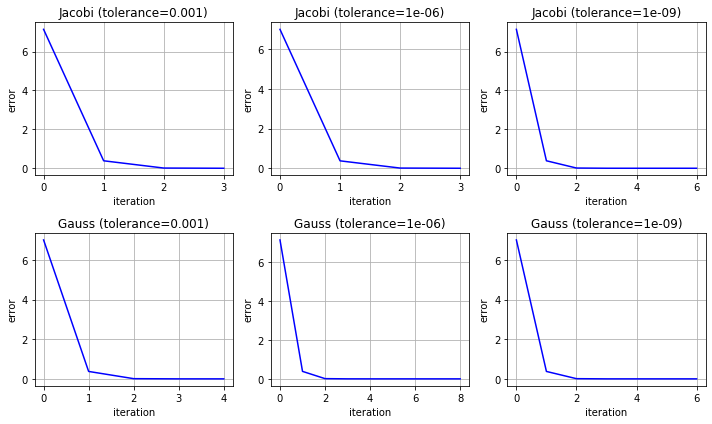

"\nWhen the tolerance becomes smaller the number of iterations increases for both jacobi and gauss seidel. This makes sense because a smaller tolerance \nrequires more accuracy, therefore a closer approximation, which would in turn mean more iterations.\n\n\nUsed AI for creating the creation of the arrays for error\nwhy you needed to use an AI : The first time around I was really confused on how to structure the arrays. \nEariler I was using a very jank nested for loop that didn't properly store values. \nI realized that there might be some function or logic I was missing when trying to create the code. \nthe AI prompt you used: If I am creating a code that computes values, measures how much those values have changed,\nand stores that change, and stops if that change is small, what are some components or functions that could be integrated \ninto a forloop in order for it to run better. \nAnd what are some possible solutions to my values getting overwritten when values get entered into 

In [13]:
import time
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        if not np.isfinite(x_new).all():
            print("Jacobi diverged at iteration", k)
            return x_new, k
            # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations



def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        if not np.isfinite(x_new).all():
            print("Gauss seidel diverged at iteration", k)
            return x_new, k
# Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations

# array from the system of equations from the hw
A = np.array([[3.0, -0.1, -0.2],[0.1, 7.0, -0.3],[0.3, -0.2, 10.0]], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

x0 = np.zeros(3)
maxit = 500

tolerances = [1e-3, 1e-6, 1e-9]




def jacobierror_list(A, b, x0, tol, maxit):
    n = len(b)
    x = x0.copy()
    err = []
    for k in range(maxit):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = 0.0
            for j in range(n):
                if j != i:
                    s += A[i][j] * x[j]
            x_new[i] = (b[i] - s) / A[i][i]

        e = np.linalg.norm(x_new - x, ord=np.inf)
        err.append(e)

        if e < tol:
            return err, k
        x = x_new
    return err, maxit


def gausserror_list(A, b, x0, tol, maxit):
    n = len(b)
    x = x0.copy()
    err = []
    for k in range(maxit):
        x_new = x.copy()
        for i in range(n):
            s1 = 0.0
            for j in range(i):
                s1 += A[i][j] * x_new[j]
            s2 = 0.0
            for j in range(i+1, n):
                s2 += A[i][j] * x[j]
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        e = np.linalg.norm(x_new - x, ord=np.inf)
        err.append(e)

        if e < tol:
            return err, k
        x = x_new
    return err, maxit


# collect iteration and error
iterationsList = []
error = []

for tol in tols:
    solJ, itJ = jacobi(A, b, x0, tol, maxit)
    errJ, _ = jacobierror_list(A, b, x0, tol, maxit)

    solG, itG = gauss_seidel(A, b, x0, tol, maxit)
    errG, _ = gausserror_list(A, b, x0, tol, maxit)

    iterationsList.append(itJ)
    error.append(errJ)

    iterationsList.append(itG)
    error.append(errG)


plt.figure(figsize=(10, 6))

for i in range(len(iterationsList)):
    x = np.arange(0, len(error[i]), 1)
    y = error[i]

    if i < 3:
        name = "Jacobi"
        tol_used = tols[i]
        subplot_index = i + 1      # top row: 1,2,3
    else:
        name = "Gauss"
        tol_used = tols[i - 3]
        subplot_index = i + 1      # bottom row: 4,5,6

    plt.subplot(2, 3, subplot_index)
    plt.plot(x, y, 'b-')
    plt.title(f"{name} (tolerance={tol_used})")
    plt.xlabel("iteration")
    plt.ylabel("error")
    plt.grid(True)

plt.tight_layout()
plt.show()


"""
When the tolerance becomes smaller the number of iterations increases for both jacobi and gauss seidel. This makes sense because a smaller tolerance 
requires more accuracy, therefore a closer approximation, which would in turn mean more iterations.


Used AI for creating the creation of the arrays for error
why you needed to use an AI : The first time around I was really confused on how to structure the arrays. 
Eariler I was using a very jank nested for loop that didn't properly store values. 
I realized that there might be some function or logic I was missing when trying to create the code. 
the AI prompt you used: If I am creating a code that computes values, measures how much those values have changed,
and stores that change, and stops if that change is small, what are some components or functions that could be integrated 
into a forloop in order for it to run better. 
And what are some possible solutions to my values getting overwritten when values get entered into my function?
"""
